# AI vs Human Text Detection: Data Exploration

This notebook performs **initial data exploration and validation** for the merged dataset.
This notebok will:
1. Load the dataset
2. Inspect structure and missing values
3. Explore label distribution (class balance)
4. Examine text length distribution
5. Visualize key statistics


In [1]:
# Importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

pd.set_option('display.max_columns', None)


In [2]:
# Loading the dataset
file_path = r"C:\Users\ajha26\Desktop\IS\Data\IS_Dataset_AI_vs_Human.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded successfully!
Shape: (330962, 2)


,Text,Label
0,"Hey there, Mrs. Johnson! \n\nSo, the topic for...",1
1,"A couple in Utah, US, has been found dead in a...",1
2,A data mart is a structure/access pattern spec...,0
3,The ability of the secretariat to take on incr...,0
4,"Lee Mullen, who won almost Â£5m in a 2011 lott...",1


In [3]:
df.info()

# Checking missing values
print("\n Missing Values Summary:")
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330962 entries, 0 to 330961
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Text    330893 non-null  object
 1   Label   330962 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 5.1+ MB

 Missing Values Summary:
Text     69
Label     0
dtype: int64


In [4]:
# Handle missing or invalid entries

# Counting missing text values before cleaning
missing_before = df["Text"].isnull().sum() + (df["Text"].str.strip() == "").sum()

# Counting duplicates before cleaning (based on Text + Label)
duplicates_before = df.duplicated(subset=["Text", "Label"]).sum()

print(f" Initial dataset shape: {df.shape}")
print(f" Missing text entries: {missing_before}")
print(f" Duplicate rows: {duplicates_before}")

# Performing cleaning 
# Dropping missing or empty text
df = df.dropna(subset=["Text"])
df = df[df["Text"].str.strip() != ""]

# Dropping duplicates
df = df.drop_duplicates(subset=["Text", "Label"])

# Counting removed rows
missing_after = df["Text"].isnull().sum() + (df["Text"].str.strip() == "").sum()
duplicates_after = df.duplicated(subset=["Text", "Label"]).sum()

print("\n Cleaning complete!")
print(f" Removed missing entries: {missing_before - missing_after}")
print(f" Removed duplicate rows: {duplicates_before - duplicates_after}")
print(f" Cleaned dataset shape: {df.shape}")


 Initial dataset shape: (330962, 2)
 Missing text entries: 69
 Duplicate rows: 25929

 Cleaning complete!
 Removed missing entries: 69
 Removed duplicate rows: 25929
 Cleaned dataset shape: (305031, 2)


In [5]:
# Saving cleaned dataset
cleaned_csv_path = r"C:\Users\ajha26\Desktop\IS\Data\IS_Dataset_AI_vs_Human_Cleaned.csv"
cleaned_excel_path = r"C:\Users\ajha26\Desktop\IS\Data\IS_Dataset_AI_vs_Human_Cleaned.xlsx"


df.to_csv(cleaned_csv_path, index=False)
df.to_excel(cleaned_excel_path, index=False)

print("\n Cleaned dataset saved successfully!")
print(f" CSV file:   {cleaned_csv_path}")
print(f" Excel file: {cleaned_excel_path}")
print(f" Final shape: {df.shape}")



 Cleaned dataset saved successfully!
 CSV file:   C:\Users\ajha26\Desktop\IS\Data\IS_Dataset_AI_vs_Human_Cleaned.csv
 Excel file: C:\Users\ajha26\Desktop\IS\Data\IS_Dataset_AI_vs_Human_Cleaned.xlsx
 Final shape: (305031, 2)


Label Counts:
Label
0    168490
1    136541
Name: count, dtype: int64

Label Percentages:
Label
0    55.237009
1    44.762991
Name: proportion, dtype: float64


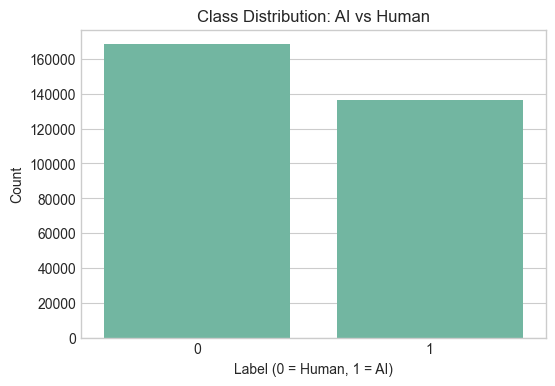

In [6]:

# Class Label Distribution: Checking if the dataset is balanced between AI-generated and Human-written samples.

# Computing label distribution
label_counts = df["Label"].value_counts()
label_percent = df["Label"].value_counts(normalize=True) * 100

print("Label Counts:")
print(label_counts)
print("\nLabel Percentages:")
print(label_percent)

# Visualization
plt.figure(figsize=(6,4))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title("Class Distribution: AI vs Human")
plt.xlabel("Label (0 = Human, 1 = AI)")
plt.ylabel("Count")
plt.show()


In [7]:
# Analyzing text lengths:
# Computing word count of each text type and visualizing distribution of text lengths and average text length per class

# Ensuring all text entries are strings
df["Text"] = df["Text"].astype(str)

# Computing text length in words 
df["Text_Length"] = df["Text"].apply(lambda x: len(str(x).split()) if isinstance(x, str) else 0)

# summary statistics
print("Text length column created successfully!")
df["Text_Length"].describe()

Text length column created successfully!


count    305031.000000
mean        140.035446
std         170.427604
min           1.000000
25%          26.000000
50%          75.000000
75%         187.000000
max        6138.000000
Name: Text_Length, dtype: float64

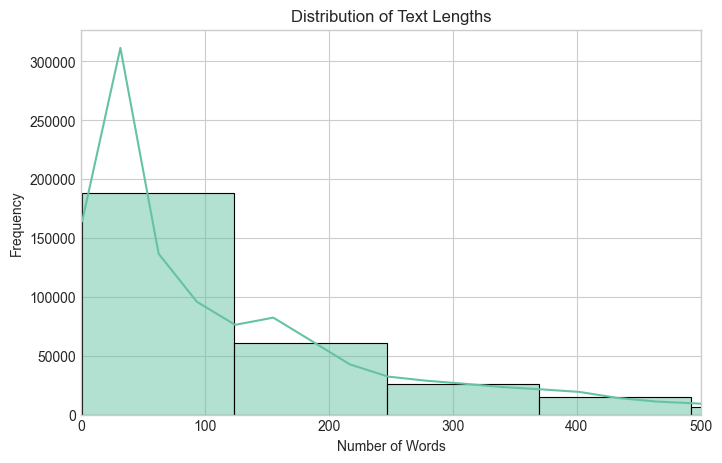

In [8]:
# Histogram of text lengths
plt.figure(figsize=(8,5))
sns.histplot(df["Text_Length"], bins=50, kde=True)
plt.title("Distribution of Text Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.xlim(0, 500) 
plt.show()


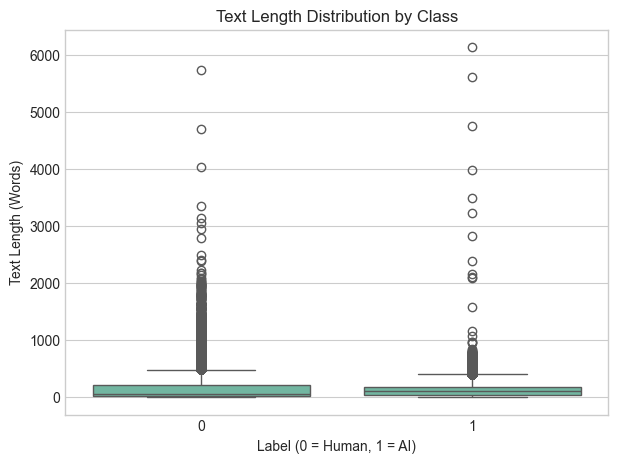

In [9]:
# Boxplot by class
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="Label", y="Text_Length")
plt.title("Text Length Distribution by Class")
plt.xlabel("Label (0 = Human, 1 = AI)")
plt.ylabel("Text Length (Words)")
plt.show()


In [10]:
zero_length_rows = df[df["Text_Length"] == 0]
print(f"Rows with 0 words: {len(zero_length_rows)}")
print(f"Percentage: {len(zero_length_rows) / len(df) * 100:.2f}%")


Rows with 0 words: 0
Percentage: 0.00%


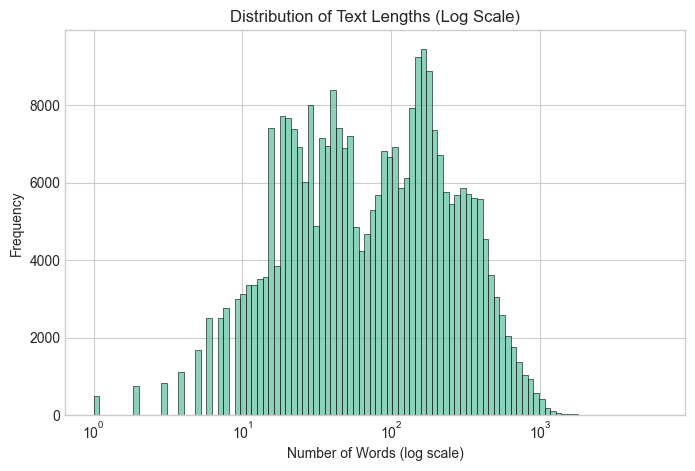

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["Text_Length"], bins=100, log_scale=(True, False))
plt.title("Distribution of Text Lengths (Log Scale)")
plt.xlabel("Number of Words (log scale)")
plt.ylabel("Frequency")
plt.show()


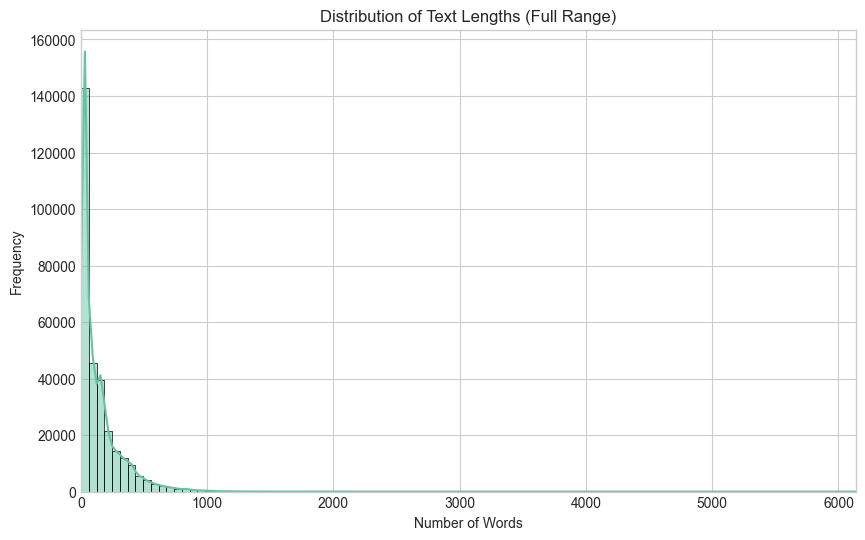

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df["Text_Length"], bins=100, kde=True)
plt.title("Distribution of Text Lengths (Full Range)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.xlim(0, df["Text_Length"].max())  
plt.show()


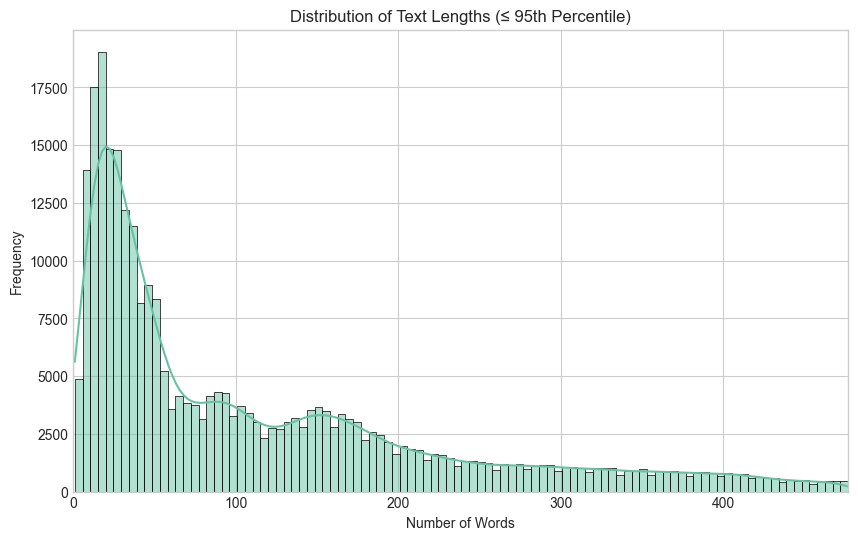

95th percentile cutoff ≈ 477 words


In [13]:
# Computing 95th percentile
p95 = df["Text_Length"].quantile(0.95)

plt.figure(figsize=(10,6))
sns.histplot(df[df["Text_Length"] <= p95]["Text_Length"], bins=100, kde=True)
plt.title("Distribution of Text Lengths (≤ 95th Percentile)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.xlim(0, p95)
plt.show()

print(f"95th percentile cutoff ≈ {p95:.0f} words")


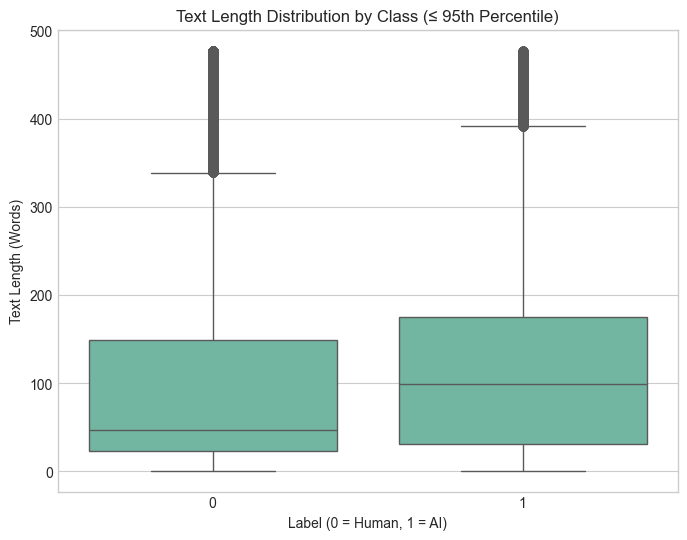

95th percentile cutoff ≈ 477 words


In [ ]:
# Computing 95th percentile cutoff - removing outliers for better visualization
p95 = df["Text_Length"].quantile(0.95)

plt.figure(figsize=(8,6))
sns.boxplot(
    data=df[df["Text_Length"] <= p95],
    x="Label",
    y="Text_Length"
)
plt.title("Text Length Distribution by Class (≤ 95th Percentile)")
plt.xlabel("Label (0 = Human, 1 = AI)")
plt.ylabel("Text Length (Words)")
plt.show()

print(f"95th percentile cutoff ≈ {p95:.0f} words")


In [17]:
# Creating a dataset with 10K rows for this IS project

import pandas as pd

# Loading cleaned full dataset
df = pd.read_excel(r"C:\Users\ajha26\Desktop\IS\Data\IS_Dataset_AI_vs_Human_Cleaned.xlsx")

# Ensuring labels are balanced (equal AI and Human)
sample_size = 5000  # per class
df_10k = (df.groupby("Label", group_keys=False)
            .apply(lambda x: x.sample(n=sample_size, random_state=42))
            .reset_index(drop=True))

print(df_10k['Label'].value_counts())
print(f" Final subset shape: {df_10k.shape}")

# Saving dataset for feature engineering and modeling
df_10k.to_excel(r"C:\Users\ajha26\Desktop\IS\Data\IS_Dataset_AI_vs_Human_10K.xlsx", index=False)
df_10k.to_csv(r"C:\Users\ajha26\Desktop\IS\Data\IS_Dataset_AI_vs_Human_10K.csv", index=False)


C:\Users\ajha26\AppData\Local\Temp\ipykernel_16048\2932684991.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=sample_size, random_state=42))


Label
0    5000
1    5000
Name: count, dtype: int64
 Final subset shape: (10000, 2)


Label Counts:
 Label
0    5000
1    5000
Name: count, dtype: int64

Label Percentages:
 Label
0    50.0
1    50.0
Name: proportion, dtype: float64


C:\Users\ajha26\AppData\Local\Temp\ipykernel_16048\2173866868.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="Set2")


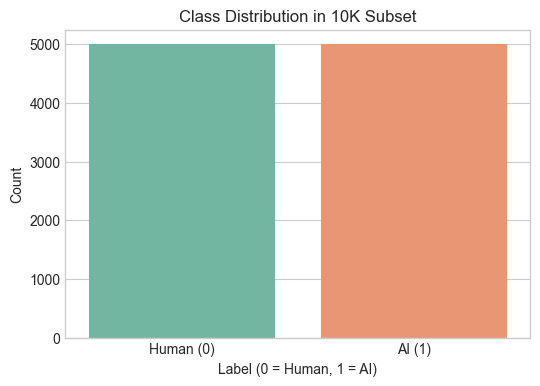

In [ ]:
# Class Balance Check (After Sampling)

# Counting labels
label_counts = df_10k["Label"].value_counts().sort_index()
label_percent = df_10k["Label"].value_counts(normalize=True).sort_index() * 100

print("Label Counts:\n", label_counts)
print("\nLabel Percentages:\n", label_percent.round(2))

# Bar plot
plt.figure(figsize=(6,4))
sns.barplot(x=label_counts.index, y=label_counts.values, palette="Set2")
plt.title("Class Distribution in 10K Subset")
plt.xlabel("Label (0 = Human, 1 = AI)")
plt.ylabel("Count")
plt.xticks([0,1], ["Human (0)", "AI (1)"])
plt.show()

C:\Users\ajha26\AppData\Local\Temp\ipykernel_16048\2009516550.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["Label"].value_counts().index,
C:\Users\ajha26\AppData\Local\Temp\ipykernel_16048\2009516550.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_10k["Label"].value_counts().index,


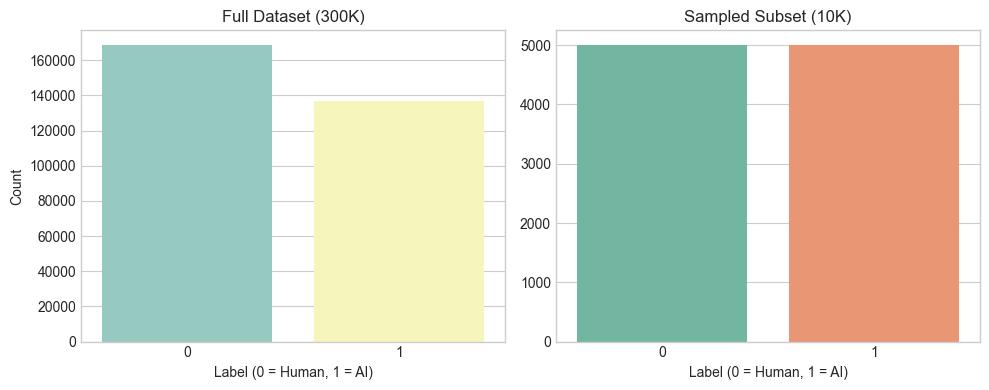

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

# Full dataset
sns.barplot(x=df["Label"].value_counts().index,
            y=df["Label"].value_counts().values,
            ax=axes[0], palette="Set3")
axes[0].set_title("Full Dataset (300K)")
axes[0].set_xlabel("Label (0 = Human, 1 = AI)")
axes[0].set_ylabel("Count")

# Subset
sns.barplot(x=df_10k["Label"].value_counts().index,
            y=df_10k["Label"].value_counts().values,
            ax=axes[1], palette="Set2")
axes[1].set_title("Sampled Subset (10K)")
axes[1].set_xlabel("Label (0 = Human, 1 = AI)")

plt.tight_layout()
plt.show()


95th percentile cutoff: 477 words
Full dataset mean length: 112.4
Subset mean length: 113.44


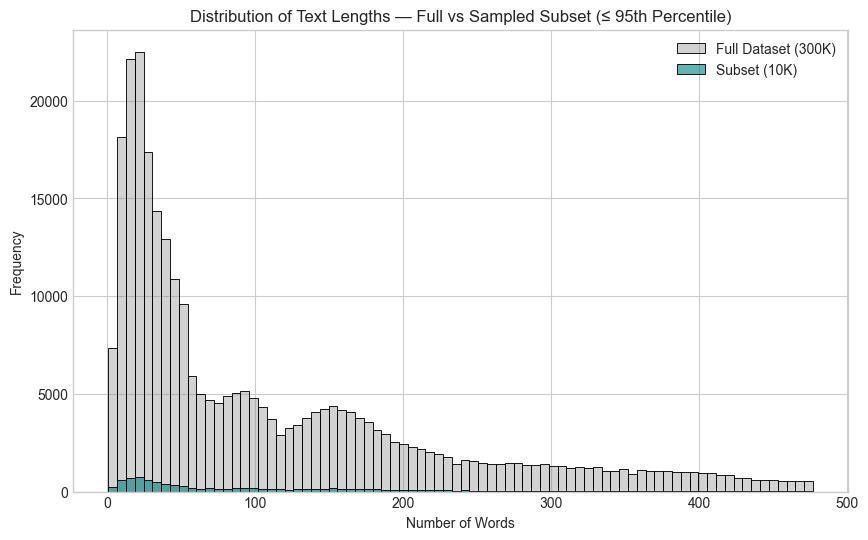

In [20]:
# Text-Length Distribution for 10K dataset:

# Computing text lengths (in words)
df["Text_Length"] = df["Text"].astype(str).apply(lambda x: len(x.split()))
df_10k["Text_Length"] = df_10k["Text"].astype(str).apply(lambda x: len(x.split()))

# Computing 95th percentile cutoff from full dataset
p95 = df["Text_Length"].quantile(0.95)

print(f"95th percentile cutoff: {p95:.0f} words")

# Filtering both datasets for visualization
df_trimmed = df[df["Text_Length"] <= p95]
df_10k_trimmed = df_10k[df_10k["Text_Length"] <= p95]

# Comparing mean lengths
print("Full dataset mean length:", round(df_trimmed["Text_Length"].mean(), 2))
print("Subset mean length:", round(df_10k_trimmed["Text_Length"].mean(), 2))

# Overlayed histograms
plt.figure(figsize=(10,6))
sns.histplot(df_trimmed["Text_Length"], bins=80, color="gray", label="Full Dataset (300K)", alpha=0.35)
sns.histplot(df_10k_trimmed["Text_Length"], bins=80, color="teal", label="Subset (10K)", alpha=0.6)
plt.title("Distribution of Text Lengths — Full vs Sampled Subset (≤ 95th Percentile)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.legend()
plt.show()


In [21]:
# Five-number summary for text length (10K subset)

if "Text_Length" not in df_10k.columns:
    df_10k["Text_Length"] = df_10k["Text"].astype(str).apply(lambda x: len(x.split()))

# Computing five-number summary
five_num_summary = df_10k["Text_Length"].describe(percentiles=[0.25, 0.5, 0.75])

# results
summary_df = pd.DataFrame({
    "Statistic": ["Minimum", "25th Percentile (Q1)", "Median (Q2)", "75th Percentile (Q3)", "Maximum"],
    "Value": [
        df_10k["Text_Length"].min(),
        five_num_summary["25%"],
        five_num_summary["50%"],
        five_num_summary["75%"],
        df_10k["Text_Length"].max()
    ]
})

print("Five-Number Summary for Text Length (10K Dataset):")
display(summary_df)


Five-Number Summary for Text Length (10K Dataset):


,Statistic,Value
0,Minimum,1.0
1,25th Percentile (Q1),27.0
2,Median (Q2),80.0
3,75th Percentile (Q3),188.0
4,Maximum,1819.0
